In [1]:
# 全局设置
import os
import datetime as dt
import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings('ignore', category=PerformanceWarning)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False# 正确显示负号
from IPython.display import HTML

# 策略测试

在 QuantStudio 中, 用户通过定义策略信号因子以及账户因子来实现策略回测

In [2]:
# 参数设置
from QuantStudio.Factor.HDF5DB import HDF5DB
HDB = HDF5DB(args={"MainDir": "../data/HDF5"}).connect()

StartDT, EndDT = dt.datetime(2025, 1, 1), dt.datetime(2025, 3, 31)# 数据起止时间
TestStartDT, TestEndDT = dt.datetime(2025, 2, 1), EndDT# 测试起止时间

FT = HDB.getTable("stock_cn_day_bar")
DTRuler = FT.getDateTime(start_dt=StartDT, end_dt=EndDT)
TestDTs = FT.getDateTime(start_dt=TestStartDT, end_dt=TestEndDT)
SectionIDs = IDs = FT.getID()

# 再平衡时点序列
from QuantStudio.Tools.DateTimeFun import getMonthLastDateTime
BalanceDTs = getMonthLastDateTime(DTRuler)# 月末

/home/lenovo/PythonEnv/QS312/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


2026-03-18 17:36:32,147 | QS | INFO : 开始初始化计算...
2026-03-18 17:36:32,152 | QS | INFO : 初始化计算完成, 耗时 0.003686429001390934 秒
2026-03-18 17:36:32,152 | QS | INFO : 开始准备计算...
2026-03-18 17:36:32,153 | QS | INFO : 准备计算完成, 耗时 1.225003506988287e-05 秒
2026-03-18 17:36:32,153 | QS | INFO : 开始正式计算...
2026-03-18 17:36:33,449 | QS | INFO : 正式计算完成, 耗时 1.295116710010916 秒


,绝对表现,基准表现,相对表现
起始时点,2025-02-01,2025-02-01,2025-02-01
结束时点,2025-03-31,2025-03-31,2025-03-31
时点数,59,59,59
总收益率,53.60%,-26.10%,1305.23%
年化收益率,1389.26%,-85.09%,1670687904.60%
年化波动率,1810.97%,5051.07%,5398.11%
Sharpe比率,0.77,-0.02,309495.24
收益风险比,0.77,-0.02,309495.24
胜率,72.88%,54.24%,44.07%
最大回撤率,88.98%,94.83%,741.67%

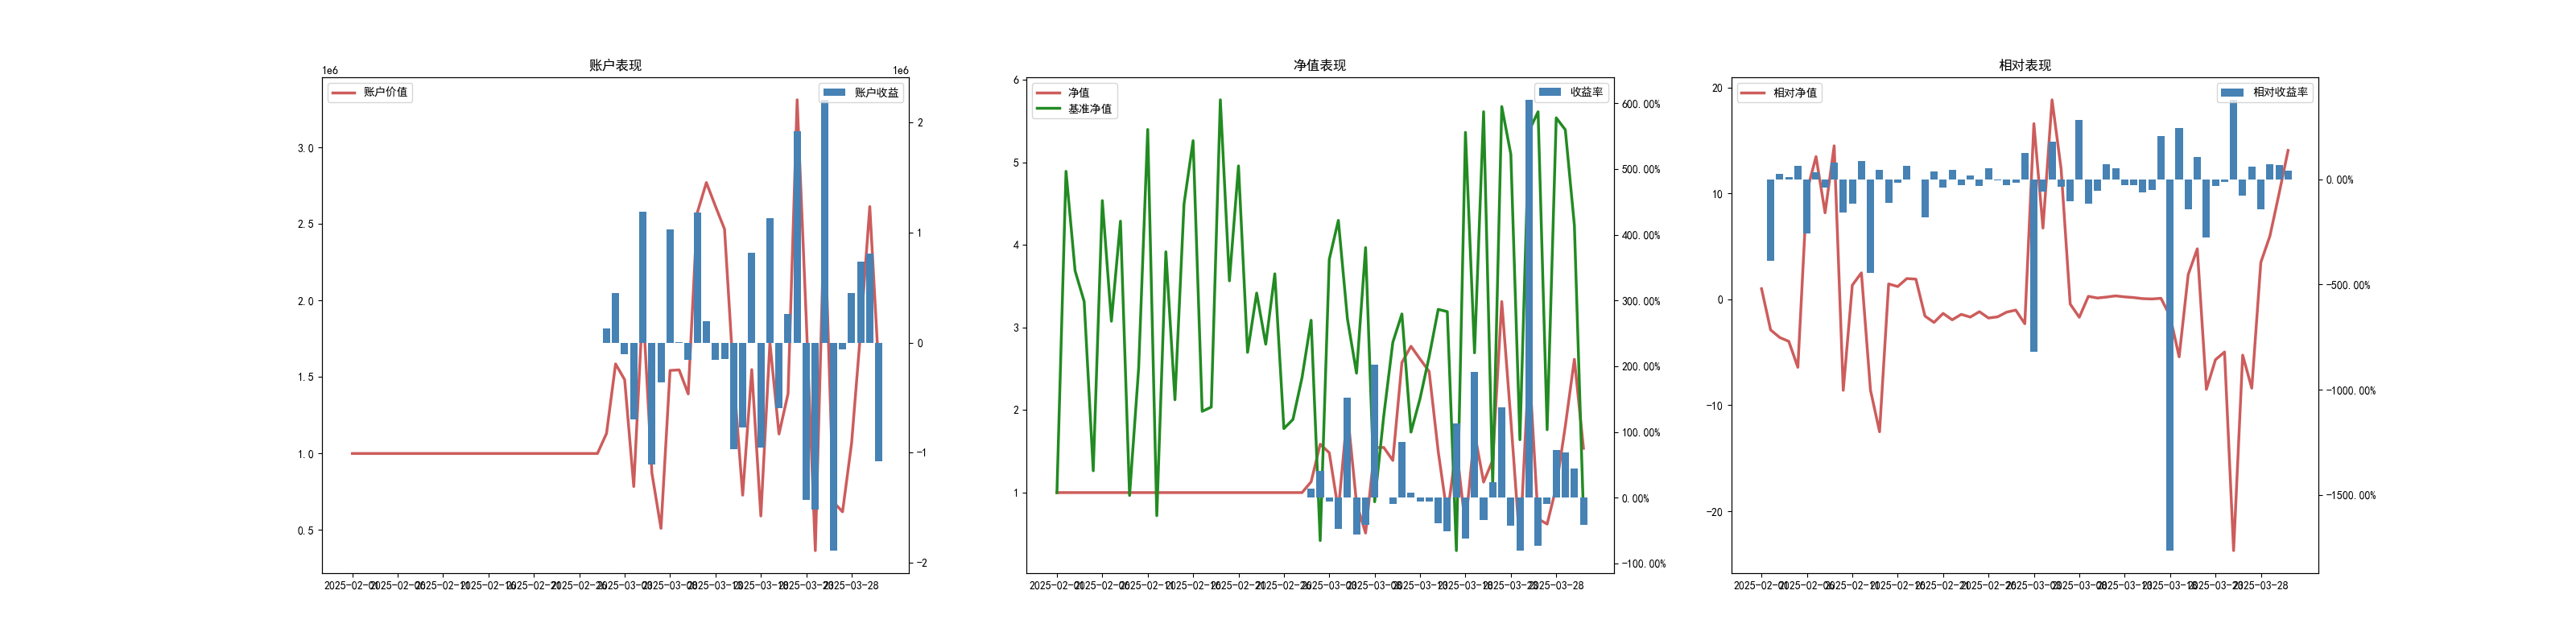

In [3]:
# 策略测试
from QuantStudio.Core.CalcEngine import Engine, ParallelEngine
from QuantStudio.Core.Node import DTLocalContext, DTInitData
from QuantStudio.Factor.Factor import FactorContext
from QuantStudio.Factor.BasicOperator import rename
import QuantStudio.Factor.FactorOperator as fo
from QuantStudio.Factor.FactorCache import FeatherFactorCache
from QuantStudio.BackTest.BackTestModel import BTReport
from QuantStudio.BackTest.Strategy.Strategy import MakeAccount, AccountReport

FT = HDB.getTable("stock_cn_day_bar")
Price = FT.getFactor("close")

FT = HDB.getTable("stock_cn_status")
IfListed = FT.getFactor("if_listed")

FT = HDB.getTable("stock_cn_factor_value")
EP = FT.getFactor("ep_ttm")

Mask = (IfListed == 1)

# 策略信号: EP TTM 属于前 20% 的股票等权配置
StrategySignal = fo.SectionRank(ascending=True, uniformization=True)(EP, mask=Mask, factor_args={"CalcDTRuler": BalanceDTs}) >= 0.8
StrategySignal = rename(StrategySignal / fo.Aggregate(aggr_func=np.nansum)(StrategySignal), factor_name="Signal")# 归一化

# 账户因子
Account = MakeAccount(signal_type="目标权重", init_cash=1e6, start_dt=TestDTs[0])(last_price=Price, signal=StrategySignal)

# 基准因子
FT = HDB.getTable("index_cn_day_bar")
BmkNV = FT.getFactor("close", args={"SectionIDs": ["000905.SH"]})

# 策略报告
StrategyReport = AccountReport(account=Account, bmk_nv=BmkNV, args={"GenReport": True})

NodeList = [StrategyReport]
Report = BTReport(bt_node_list=NodeList)

with FeatherFactorCache(args={"DTRuler": DTRuler, "CacheDir": "../data/Cache", "StartMode": "new"}) as Cache:
    with FactorContext(DTRuler=DTRuler, DefaultSectionIDs=SectionIDs, FactorDataCache=Cache) as Context:
        with Engine() as ExecEngine:
            Rslt = ExecEngine.run([Report], Context, fwd_data_list=[DTLocalContext(DTs=TestDTs)], init_data_list=[DTInitData(DTRange=(TestDTs[0], TestDTs[-1]))])

display(HTML(Rslt[0]["Report"]))

2026-03-18 17:36:45,465 | QS | WARNING : 算子 makeStrategy(QSID: bf71de019df7a4b05e1b132aade59a64939639fb637dc2adb3a58b428bd2bfcc) 为自身迭代且滚动窗口模式，在缓存的不同状态下产生的数据会不一致，所以该算子作用的因子将强制不使用缓存!


2026-03-18 17:36:45,541 | QS | INFO : 开始初始化计算...
2026-03-18 17:36:45,542 | QS | INFO : 初始化计算完成, 耗时 0.0008268500096164644 秒
2026-03-18 17:36:45,542 | QS | INFO : 开始准备计算...
2026-03-18 17:36:45,543 | QS | INFO : 准备计算完成, 耗时 9.585986845195293e-06 秒
2026-03-18 17:36:45,544 | QS | INFO : 开始正式计算...
2026-03-18 17:36:46,150 | QS | INFO : 正式计算完成, 耗时 0.6059720480116084 秒


,绝对表现,基准表现,相对表现
起始时点,2025-02-01,2025-02-01,2025-02-01
结束时点,2025-03-31,2025-03-31,2025-03-31
时点数,59,59,59
总收益率,-26.93%,-26.10%,22537644754.15%
年化收益率,-98.23%,-85.09%,470073675122859152084838761532261397258825809010884608.00%
年化波动率,7582.85%,5051.07%,9518.09%
Sharpe比率,-0.01,-0.02,49387387428937826878062798003305972034165496872960.00
收益风险比,-0.01,-0.02,49387387428937826878062798003305972034165496872960.00
胜率,52.54%,54.24%,55.93%
最大回撤率,100.00%,94.83%,289812.19%

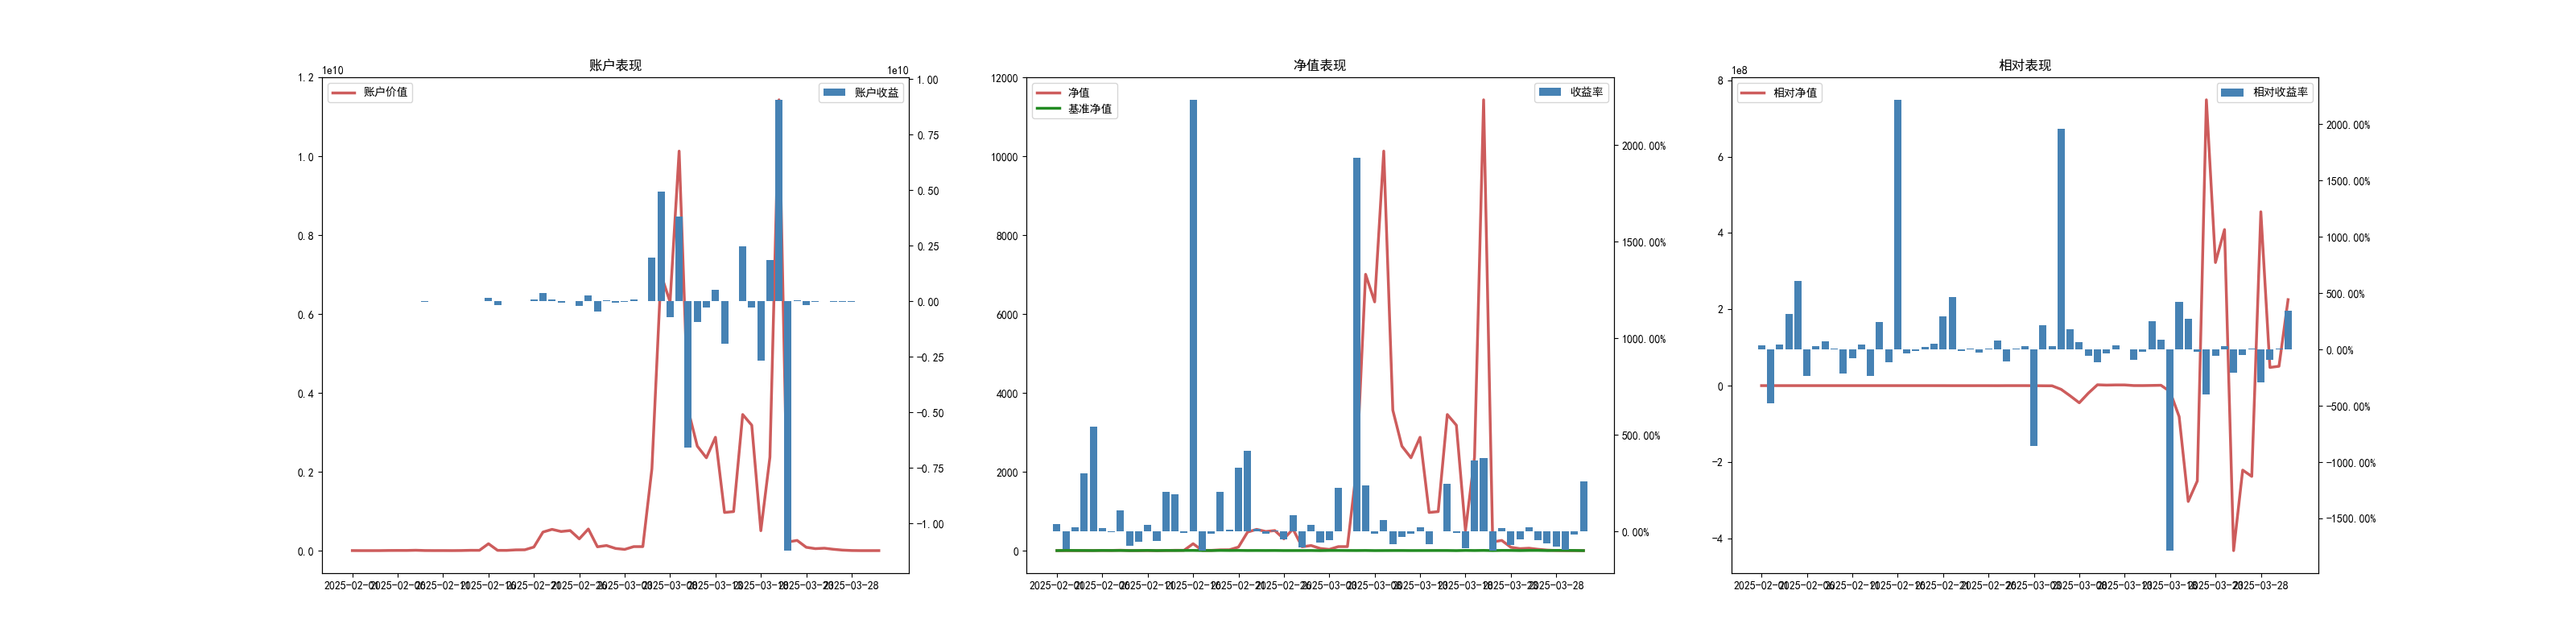

In [ ]:
# 策略测试
from QuantStudio.Core.CalcEngine import Engine, ParallelEngine
from QuantStudio.Core.Node import DTLocalContext, DTInitData
from QuantStudio.Factor.Factor import FactorContext
from QuantStudio.Factor.BasicOperator import rename
import QuantStudio.Factor.FactorOperator as fo
from QuantStudio.Factor.FactorCache import FeatherFactorCache
from QuantStudio.BackTest.BackTestModel import BTReport
from QuantStudio.BackTest.Strategy.Strategy import MakeStrategy, AccountReport

class MakeMyStrategy(MakeStrategy):
    def genSignal(self, f, idt, x, last_price, cash, position_num, args):
        """买入 EP 最大的那只股票"""
        iID = x[0].iloc[0].idxmax()
        return pd.Series(1, index=[iID])

FT = HDB.getTable("stock_cn_day_bar")
Price = FT.getFactor("close")

FT = HDB.getTable("stock_cn_status")
IfListed = FT.getFactor("if_listed")

FT = HDB.getTable("stock_cn_factor_value")
EP = FT.getFactor("ep_ttm")

# 策略因子
Strategy = MakeMyStrategy(signal_type="目标权重", init_cash=1e6, start_dt=TestDTs[0], x_lookback=[0], x_section_ids=[None])(EP, last_price=Price)

# 基准因子
FT = HDB.getTable("index_cn_day_bar")
BmkNV = FT.getFactor("close", args={"SectionIDs": ["000905.SH"]})

# 策略报告
StrategyReport = AccountReport(account=Strategy, bmk_nv=BmkNV, args={"GenReport": True})

NodeList = [StrategyReport]
Report = BTReport(bt_node_list=NodeList)

with FeatherFactorCache(args={"DTRuler": DTRuler, "CacheDir": "../data/Cache", "StartMode": "new"}) as Cache:
    with FactorContext(DTRuler=DTRuler, DefaultSectionIDs=SectionIDs, FactorDataCache=Cache) as Context:
        with Engine() as ExecEngine:
            Rslt = ExecEngine.run([Report], Context, fwd_data_list=[DTLocalContext(DTs=TestDTs)], init_data_list=[DTInitData(DTRange=(TestDTs[0], TestDTs[-1]))])

display(HTML(Rslt[0]["Report"]))